In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.model import NeuralNetwork

from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression

# **Nonlinear Decision Boundary**

This notebook demonstrates the core advantage of a neural network over logistic regression — the ability to learn nonlinear decision boundaries.

Dataset: `make_moons` — two interleaving crescents that are not linearly separable.

Logistic regression can only produce a straight decision boundary.  

A neural network with a hidden layer can curve it to fit the data.

## **Dataset**

500 samples from `make_moons` with `noise=0.1`, `random_state=42`.

No train-test split — the goal here is visualization, not generalization measurement.

In [2]:
X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
y = y.reshape(-1, 1)

## **Neural Network**

- Input dim: 2
- Hidden dim: 32
- Learning rate: 0.1
- Epochs: 10000

In [3]:
model = NeuralNetwork(
    input_dim=2,
    hidden_dim=32,
    learning_rate=0.1,
    epochs=10000
)
model.fit(X, y)

In [4]:
from src.metrics import accuracy
print(f"NN accuracy: {accuracy(y, model.predict(X)):.4f}")
print(f"Initial loss: {model.loss_history[0]:.4f}")
print(f"Final loss: {model.loss_history[-1]:.4f}")

NN accuracy: 0.8920
Initial loss: 0.6932
Final loss: 0.2098


## **Logistic Regression Baseline**

Trained on the same data with default settings.  
Its boundary will be a straight line — the nonlinearity ceiling.

In [5]:
lr = LogisticRegression()
lr.fit(X, y.ravel())

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [6]:
print(f"LR accuracy: {lr.score(X, y.ravel()):.4f}")

LR accuracy: 0.8720


## **Decision Boundary Visualization**

Both models are plotted using their probability outputs rather than hard predictions. This shows the shape of the learned boundary, not just which side of it a point falls on.

The decision boundary (black line) is drawn at probability = 0.5.

In [7]:
def plot_boundary(model, X, y, title, filename=None):
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Use probability surface, not hard predictions
    if hasattr(model, 'predict_proba'):
        try:
            Z = model.predict_proba(grid)
            # sklearn returns (n, 2), ours returns (n, 1)
            if Z.ndim == 2 and Z.shape[1] == 2:
                Z = Z[:, 1]
            Z = Z.ravel()
        except:
            Z = model.predict(grid).ravel()
    else:
        Z = model.predict(grid).ravel()

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, levels=50, alpha=0.7, cmap='coolwarm')
    plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    plt.scatter(X[:,0], X[:,1], c=y.ravel(), edgecolor='k', s=25, cmap='bwr')
    plt.title(title)
    if filename:
        os.makedirs("../experiments", exist_ok=True)
        plt.savefig(f"../experiments/{filename}", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

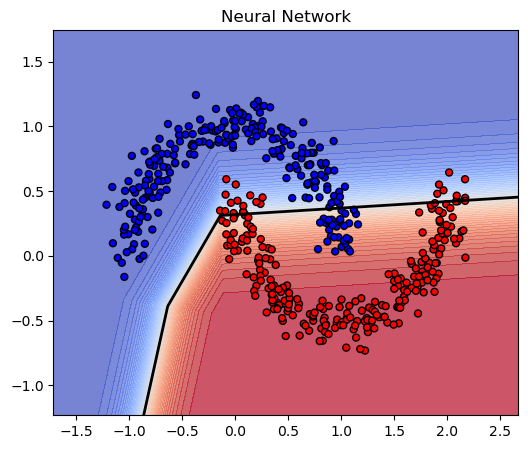

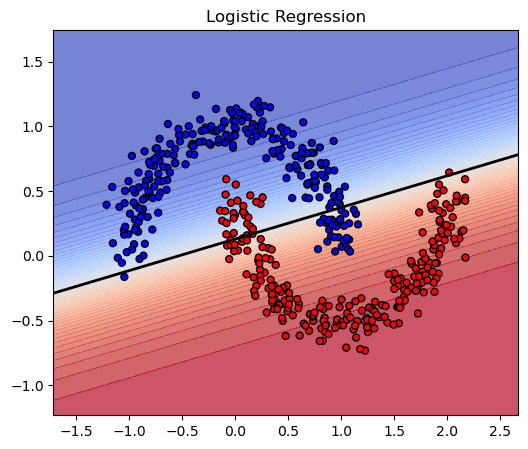

In [8]:
plot_boundary(model, X, y, "Neural Network", filename="nb03_nn_boundary.png")
plot_boundary(lr, X, y, "Logistic Regression", filename="nb03_lr_boundary.png")

## **Observations**

- Neural Network accuracy: 0.8920 — Logistic Regression: 0.8720
- The accuracy gap is small because `make_moons` with `noise=0.1` creates overlapping class regions near the boundary
- The boundary shape tells the real story: the neural network learns a curved boundary that follows the crescent structure of the data, while logistic regression is constrained to a straight line
- This demonstrates why nonlinearity matters — not always for accuracy on simple datasets, but for what the model can represent

The hidden layer is what enables this. A single-layer network (logistic regression) cannot express this curve regardless of how long it trains.